# ERCP 4-Class Classification - RegNetY-400MF




In [1]:
# =========================
# 1. Imports e configuração
# =========================

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
# =========================
# 2. Configuração principal
# =========================

# ===== CONFIGURAÇÃO PRINCIPAL =====
DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'regnety8gf_4class'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
EPOCHS = 20
PATIENCE = 5
LR_BACKBONE = 1e-5
LR_HEAD = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
BASELINE_MACRO_F1 = 0.738

# Configurações derivadas para este notebook
# Fase 1: treina apenas a cabeça; Fase 2: fine-tuning parcial do backbone.
EPOCHS_HEAD = min(5, EPOCHS)
EPOCHS_FINETUNE = EPOCHS
LR_FINETUNE = LR_BACKBONE
PIN_MEMORY = torch.cuda.is_available()

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)
print('Device:', device)


Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/regnety8gf_4class
Models: /mounts/mecd-ap-g5/models/regnety8gf_4class
Device: cuda


In [3]:
# =========================
# 3. Funções auxiliares
# =========================

def clean_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def normalize_label(x):
    """Mapeia labels originais para as 4 classes do enunciado."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s_low = s.lower().replace('_', ' ').replace('-', ' ')

    if s in ['Benign Stricture', 'Malignant Stricture', 'Stricture']:
        return 'Stricture'
    if 'stricture' in s_low or 'stenosis' in s_low or 'estenose' in s_low:
        return 'Stricture'
    if 'leak' in s_low:
        return 'Biliary Leaks'
    if 'lithiasis' in s_low or 'stone' in s_low or 'stones' in s_low or 'calculus' in s_low:
        return 'Lithiasis'
    if 'normal' in s_low:
        return 'Normal'
    return np.nan


def resolve_image_path(value):
    """Resolve caminhos absolutos ou relativos às pastas do dataset."""
    p = Path(str(value))
    candidates = []

    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend([
            DATASET_DIR / p,
            PROCESSED_IMAGES_DIR / p,
            PROCESSED_IMAGES_DIR / p.name,
            DATA_ROOT / p,
        ])

    for c in candidates:
        if c.exists():
            return str(c)

    return str(candidates[0]) if candidates else str(p)


In [4]:
# =========================
# 4. Carregamento dos metadados via CSV
# =========================

assert METADATA_PATH.exists(), f"METADATA_PATH não existe: {METADATA_PATH}"
assert PROCESSED_IMAGES_DIR.exists(), f"PROCESSED_IMAGES_DIR não existe: {PROCESSED_IMAGES_DIR}"

df = pd.read_csv(METADATA_PATH)
print('Shape original:', df.shape)
display(df.head())
print('Colunas:', df.columns.tolist())

# 1) Coluna da classe/diagnóstico
label_col = 'Label'
if label_col not in df.columns:
    candidate_label_cols = ['label', 'class', 'diagnosis', 'target', 'Category', 'category', 'Finding']
    label_col = next((c for c in candidate_label_cols if c in df.columns), None)

if label_col is None:
    raise ValueError(f'Não encontrei coluna de label. Colunas disponíveis: {df.columns.tolist()}')

# 2) Filtrar imagens marcadas como Keep e remover não etiquetadas
EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled', 'nan', ''}

if 'Keep' in df.columns:
    keep_mask = df['Keep'].astype(str).str.strip().str.lower().eq('keep')
else:
    print('Aviso: coluna Keep não encontrada. Vou usar todas as linhas.')
    keep_mask = pd.Series(True, index=df.index)

raw_label = df[label_col].astype(str).str.strip()
label_mask = ~raw_label.str.lower().isin(EXCLUDED_LABELS)

df = df[keep_mask & label_mask].copy()

# 3) Mapear para as 4 classes finais
class_names = ['Biliary Leaks', 'Lithiasis', 'Stricture', 'Normal']
CLASS_NAMES = class_names
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df['label_4class'] = df[label_col].apply(normalize_label)
df = df[df['label_4class'].isin(class_names)].copy()
df['target'] = df['label_4class'].map(class_to_idx)

print('Shape após filtro:', df.shape)
print('Distribuição 4 classes:')
print(df['label_4class'].value_counts())
print('\nDistribuição original depois do filtro:')
print(df[label_col].value_counts())

# 4) Resolver caminhos das imagens processadas
candidate_path_cols = [
    'processed_image_path', 'image_path', 'Image_Path', 'path', 'filepath',
    'filename', 'file_name', 'image', 'Image'
]
path_col = next((c for c in candidate_path_cols if c in df.columns), None)
if path_col is None:
    raise ValueError(f'Não encontrei coluna de caminho. Colunas disponíveis: {df.columns.tolist()}')

print('\nColuna de caminho usada:', path_col)
df['image_path'] = df[path_col].apply(resolve_image_path)
df['exists'] = df['image_path'].apply(lambda p: Path(p).exists())

print('Imagens existentes:', df['exists'].sum(), '/', len(df))
if df['exists'].sum() < len(df):
    print('Exemplos sem ficheiro:')
    display(df.loc[~df['exists'], [path_col, 'image_path']].head())

df = df[df['exists']].reset_index(drop=True)
print('Shape final com ficheiros existentes:', df.shape)
display(df[['image_path', 'label_4class', 'target']].head())

# 5) Detetar coluna de paciente/grupo para split por paciente
candidate_group_cols = [
    'patient_id', 'Patient_ID', 'patient', 'Patient', 'case_id', 'Case_ID',
    'exam_id', 'Exam_ID', 'study_id', 'StudyInstanceUID'
]
group_col = next((c for c in candidate_group_cols if c in df.columns), None)

if group_col is None:
    print('Aviso: não encontrei coluna de paciente. Vou criar grupos a partir do nome do ficheiro.')
    df['group_id'] = df['image_path'].apply(lambda p: Path(p).stem.split('_')[0].split('-')[0])
    group_col = 'group_id'
else:
    print('Coluna de grupo usada:', group_col)

print('N grupos:', df[group_col].nunique())


Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Colunas: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']
Shape após filtro: (1568, 14)
Distribuição 4 classes:
label_4class
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64

Distribuição original depois do filtro:
Label
Lithiasis              726
Malignant Stricture    329
Normal                 299
Biliary Leaks          151
Benign Stricture        63
Name: count, dtype: int64

Coluna de caminho usada: processed_image_path
Imagens existentes: 1568 / 1568
Shape final com ficheiros existentes: (1568, 16)


,image_path,label_4class,target
0,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3
1,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2
2,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3
3,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2
4,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2


Coluna de grupo usada: patient_id
N grupos: 436


In [ ]:
# ===============================================================
# 4B. Alternativa: dataset organizado por pastas/classes
# ===============================================================
# Usa esta célula apenas se não tiveres CSV.
# Nesse caso, comenta a célula 4 e descomenta este bloco.

# rows = []
# for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff']:
#     for p in PROCESSED_IMAGES_DIR.rglob(ext):
#         raw_label = p.parent.name
#         label_4 = normalize_label(raw_label)
#         if label_4 in ['Biliary Leaks', 'Lithiasis', 'Stricture', 'Normal']:
#             rows.append({'image_path': str(p), 'label_4class': label_4, 'group_id': p.stem})
#
# df = pd.DataFrame(rows)
# class_names = ['Biliary Leaks', 'Lithiasis', 'Stricture', 'Normal']
# CLASS_NAMES = class_names
# class_to_idx = {c: i for i, c in enumerate(class_names)}
# idx_to_class = {i: c for c, i in class_to_idx.items()}
# df['target'] = df['label_4class'].map(class_to_idx)
# group_col = 'group_id'
# print(df.shape)
# print(df['label_4class'].value_counts())
# display(df.head())


In [5]:
# =========================
# 5. Split treino/val/teste
# =========================

# Split 70/15/15 com GroupShuffleSplit quando existe coluna de paciente/grupo.
if df[group_col].nunique() < len(df):
    split1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(split1.split(df, df['target'], groups=df[group_col]))
    train_df = df.iloc[train_idx].copy().reset_index(drop=True)
    temp_df = df.iloc[temp_idx].copy().reset_index(drop=True)

    split2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(split2.split(temp_df, temp_df['target'], groups=temp_df[group_col]))
    val_df = temp_df.iloc[val_idx].copy().reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].copy().reset_index(drop=True)
else:
    print('Aviso: cada imagem tem um grupo único. Vou usar split estratificado por imagem.')
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['target'])
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['target'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{name}: {len(part)} imagens, {part[group_col].nunique()} grupos')
    print(part['label_4class'].value_counts())

# Guardar splits para reprodutibilidade
train_df.to_csv(RESULTS_DIR / 'split_train.csv', index=False)
val_df.to_csv(RESULTS_DIR / 'split_val.csv', index=False)
test_df.to_csv(RESULTS_DIR / 'split_test.csv', index=False)



train: 1088 imagens, 305 grupos
label_4class
Lithiasis        517
Stricture        270
Normal           212
Biliary Leaks     89
Name: count, dtype: int64

val: 268 imagens, 65 grupos
label_4class
Lithiasis        113
Stricture         54
Normal            51
Biliary Leaks     50
Name: count, dtype: int64

test: 212 imagens, 66 grupos
label_4class
Lithiasis        96
Stricture        68
Normal           36
Biliary Leaks    12
Name: count, dtype: int64


In [6]:
# =========================
# 6. Dataset e transforms
# =========================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

valid_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = int(row["target"])
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, image_path

train_dataset = ERCPDataset(train_df, train_tfms)
val_dataset = ERCPDataset(val_df, valid_tfms)
test_dataset = ERCPDataset(test_df, valid_tfms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

xb, yb, pb = next(iter(train_loader))
print(xb.shape, yb.shape)


torch.Size([16, 3, 224, 224]) torch.Size([16])


In [7]:
# =========================
# 7. Class weights
# =========================

classes_np = np.arange(len(class_names))
class_weights_np = compute_class_weight(class_weight="balanced", classes=classes_np, y=train_df["target"].values)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

print("Class weights:")
for c, w in zip(class_names, class_weights_np):
    print(f"{c}: {w:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTHING)


Class weights:
Biliary Leaks: 3.0562
Lithiasis: 0.5261
Stricture: 1.0074
Normal: 1.2830


In [8]:
# =========================
# 8. Modelo RegNetY-400MF
# =========================

clean_cuda()

weights = models.RegNet_Y_400MF_Weights.IMAGENET1K_V2
model = models.regnet_y_400mf(weights=weights)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, len(class_names)),
)

model = model.to(device)
print(model.fc)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Downloading: "https://download.pytorch.org/models/regnet_y_400mf-e6988f5f.pth" to /mounts/mecd-ap-g5/.cache/torch/hub/checkpoints/regnet_y_400mf-e6988f5f.pth
100%|██████████| 16.8M/16.8M [00:01<00:00, 11.5MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=440, out_features=4, bias=True)
)


/tmp/ipykernel_69366/1348282287.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [9]:
# =========================
# 9. Funções de treino e avaliação
# =========================

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    pbar = tqdm(loader, leave=False)
    for images, labels, _ in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=float(loss.item()))

    epoch_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return epoch_loss, macro_f1, acc, bal_acc


def train_model(model, optimizer, epochs, phase_name="phase"):
    best_val_f1 = -1
    best_path = MODELS_DIR / f"best_{phase_name}.pt"
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_f1, train_acc, train_bal = run_one_epoch(model, train_loader, optimizer)
        val_loss, val_f1, val_acc, val_bal = run_one_epoch(model, val_loader, optimizer=None)

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_macro_f1": train_f1,
            "train_acc": train_acc,
            "train_bal_acc": train_bal,
            "val_loss": val_loss,
            "val_macro_f1": val_f1,
            "val_acc": val_acc,
            "val_bal_acc": val_bal,
        }
        history.append(row)

        print(f"[{phase_name}] Epoch {epoch:02d}/{epochs} | train F1={train_f1:.4f} | val F1={val_f1:.4f} | train loss={train_loss:.4f} | val loss={val_loss:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print(f"  Novo melhor modelo guardado: {best_path} | val macro F1={best_val_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping.")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    return pd.DataFrame(history), best_path


In [10]:
# =========================
# 10. Treino fase 1: cabeça
# =========================

history_head, best_head_path = train_model(model, optimizer, epochs=EPOCHS_HEAD, phase_name="head")
display(history_head)


  0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[head] Epoch 01/5 | train F1=0.2439 | val F1=0.2496 | train loss=1.5063 | val loss=1.4337
  Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/regnety8gf_4class/best_head.pt | val macro F1=0.2496


...

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[head] Epoch 05/5 | train F1=0.2769 | val F1=0.3043 | train loss=1.4271 | val loss=1.4058
  Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/regnety8gf_4class/best_head.pt | val macro F1=0.3043


,phase,epoch,train_loss,train_macro_f1,train_acc,train_bal_acc,val_loss,val_macro_f1,val_acc,val_bal_acc
0,head,1,1.506285,0.243866,0.278493,0.254300,1.433658,0.249586,0.250000,0.280956
1,head,2,1.487038,0.243319,0.262868,0.267669,1.427715,0.247215,0.324627,0.272227
2,head,3,1.447264,0.262900,0.287684,0.287653,1.414313,0.284432,0.309701,0.324313
3,head,4,1.472385,0.257768,0.283088,0.278637,1.416933,0.257920,0.309701,0.326340
4,head,5,1.427106,0.276871,0.299632,0.307733,1.405838,0.304255,0.328358,0.351360


In [13]:
# =========================
# 11. Fine-tuning parcial
# =========================

for param in model.parameters():
    param.requires_grad = False

for param in model.trunk_output.block4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {num_trainable:,} / {num_total:,}")

history_ft, best_ft_path = train_model(model, optimizer, epochs=EPOCHS_FINETUNE, phase_name="finetune_block4")
display(history_ft)


Parâmetros treináveis: 3,054,206 / 3,904,908


  0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


...

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7dfb4097d3f0>Traceback (most recent call last):
  File "/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
  File "/opt/conda/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dfb4097d3f0>
Traceback (most recent call last):
  File "/mounts/mecd

  0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1882049771.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[finetune_block4] Epoch 12/20 | train F1=0.4471 | val F1=0.3527 | train loss=1.2134 | val loss=1.3695
Early stopping.


,phase,epoch,train_loss,train_macro_f1,train_acc,train_bal_acc,val_loss,val_macro_f1,val_acc,val_bal_acc
0,finetune_block4,1,1.397246,0.306408,0.337316,0.331804,1.385294,0.308115,0.339552,0.343395
1,finetune_block4,2,1.336340,0.358449,0.380515,0.400989,1.389531,0.338116,0.361940,0.358423
2,finetune_block4,3,1.344737,0.359554,0.379596,0.407237,1.390530,0.314732,0.332090,0.323998
3,finetune_block4,4,1.360515,0.339868,0.363971,0.373213,1.384911,0.328916,0.343284,0.343734
4,finetune_block4,5,1.329716,0.343898,0.365809,0.387695,1.382655,0.362294,0.388060,0.378275
5,finetune_block4,6,1.294161,0.396379,0.411765,0.445569,1.379364,0.358320,0.376866,0.372281
6,finetune_block4,7,1.307148,0.386475,0.402574,0.435482,1.385546,0.365324,0.376866,0.375047
7,finetune_block4,8,1.297622,0.384666,0.402574,0.433463,1.376755,0.359706,0.380597,0.366403
8,finetune_block4,9,1.261900,0.395816,0.404412,0.458898,1.373434,0.364731,0.380597,0.380515
9,finetune_block4,10,1.261010,0.420909,0.440257,0.474698,1.377170,0.341645,0.350746,0.345894


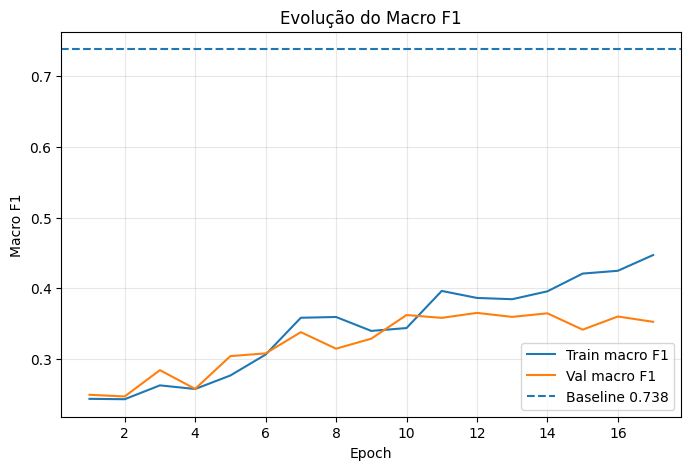

In [14]:
# =========================
# 12. Histórico de treino
# =========================

history = pd.concat([history_head, history_ft], ignore_index=True)
history.to_csv(RESULTS_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history.index + 1, history["train_macro_f1"], label="Train macro F1")
plt.plot(history.index + 1, history["val_macro_f1"], label="Val macro F1")
plt.axhline(BASELINE_MACRO_F1, linestyle="--", label="Baseline 0.738")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Evolução do Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
# =========================
# 13. Avaliação final no teste
# =========================

def predict_loader(model, loader):
    model.eval()
    probs_all, preds_all, labels_all, paths_all = [], [], [], []

    with torch.no_grad():
        for images, labels, paths in tqdm(loader):
            images = images.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(images)
                probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            probs_all.append(probs.cpu().numpy())
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.numpy())
            paths_all.extend(paths)

    return np.array(labels_all), np.array(preds_all), np.vstack(probs_all), paths_all

model.load_state_dict(torch.load(best_ft_path, map_location=device))
y_true, y_pred, y_prob, test_paths = predict_loader(model, test_loader)

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Balanced accuracy: {bal_acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Baseline macro F1: {BASELINE_MACRO_F1:.4f}")
print(f"Diferença para baseline: {macro_f1 - BASELINE_MACRO_F1:.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

try:
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    roc_auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
    pr_auc_macro = average_precision_score(y_true_bin, y_prob, average="macro")
    print(f"ROC-AUC macro OvR: {roc_auc_macro:.4f}")
    print(f"PR-AUC macro OvR: {pr_auc_macro:.4f}")
except Exception as e:
    print("Não foi possível calcular ROC-AUC/PR-AUC:", e)

results_df = pd.DataFrame({
    "image_path": test_paths,
    "true": [idx_to_class[i] for i in y_true],
    "pred": [idx_to_class[i] for i in y_pred],
})
for i, c in enumerate(class_names):
    results_df[f"prob_{c}"] = y_prob[:, i]
results_df.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
display(results_df.head())


  0%|          | 0/14 [00:00<?, ?it/s]

/tmp/ipykernel_69366/1292155067.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Accuracy: 0.4104
Balanced accuracy: 0.3375
Macro F1: 0.3178
Baseline macro F1: 0.7380
Diferença para baseline: -0.4202

Classification report:
               precision    recall  f1-score   support

Biliary Leaks       0.10      0.25      0.14        12
    Lithiasis       0.56      0.61      0.59        96
    Stricture       0.44      0.24      0.31        68
       Normal       0.22      0.25      0.23        36

     accuracy                           0.41       212
    macro avg       0.33      0.34      0.32       212
 weighted avg       0.44      0.41      0.41       212

ROC-AUC macro OvR: 0.5744
PR-AUC macro OvR: 0.2951


,image_path,true,pred,prob_Biliary Leaks,prob_Lithiasis,prob_Stricture,prob_Normal
0,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,Lithiasis,0.192610,0.378774,0.228284,0.200332
1,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Lithiasis,0.129233,0.349624,0.232133,0.289009
2,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Normal,0.183172,0.289148,0.153758,0.373923
3,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Lithiasis,0.216168,0.300681,0.215273,0.267878
4,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Lithiasis,0.236919,0.370775,0.173885,0.218420


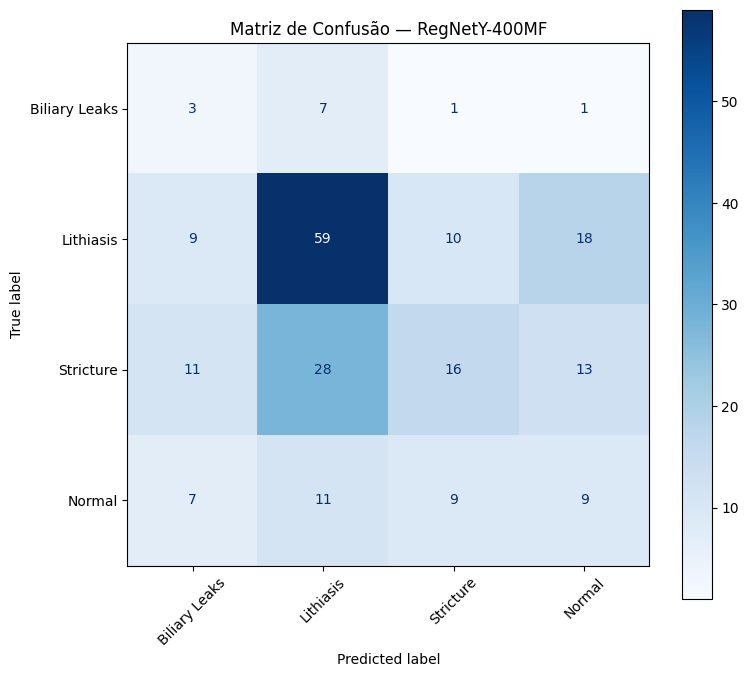

In [16]:
# =========================
# 14. Matriz de confusão
# =========================

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("Matriz de Confusão — RegNetY-400MF")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=200)
plt.show()


In [17]:
# =========================
# 15. Grad-CAM simples para RegNet
# =========================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logits.detach()

    def close(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


def denormalize(img_tensor):
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    return np.clip(img, 0, 1)


def overlay_cam(img_rgb, cam, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip((1 - alpha) * img_rgb + alpha * heatmap, 0, 1)

target_layer = model.trunk_output.block4
cam_generator = GradCAM(model, target_layer)


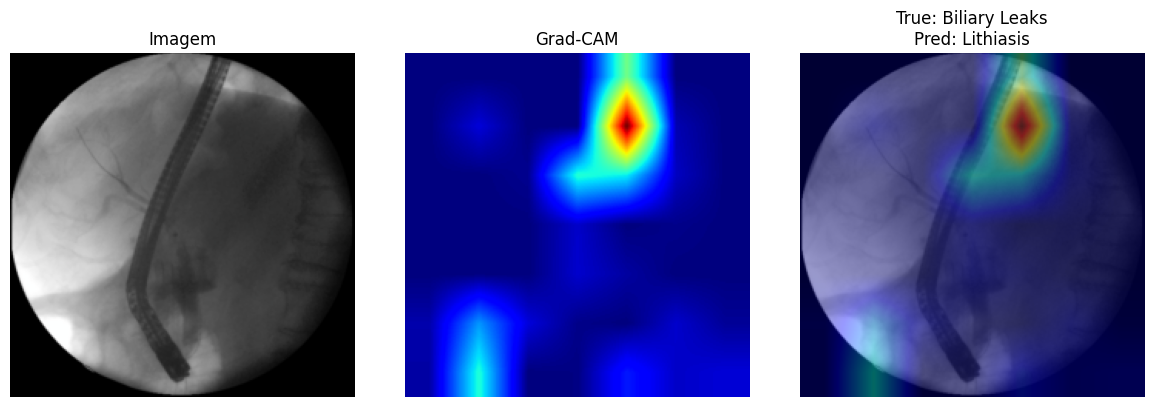

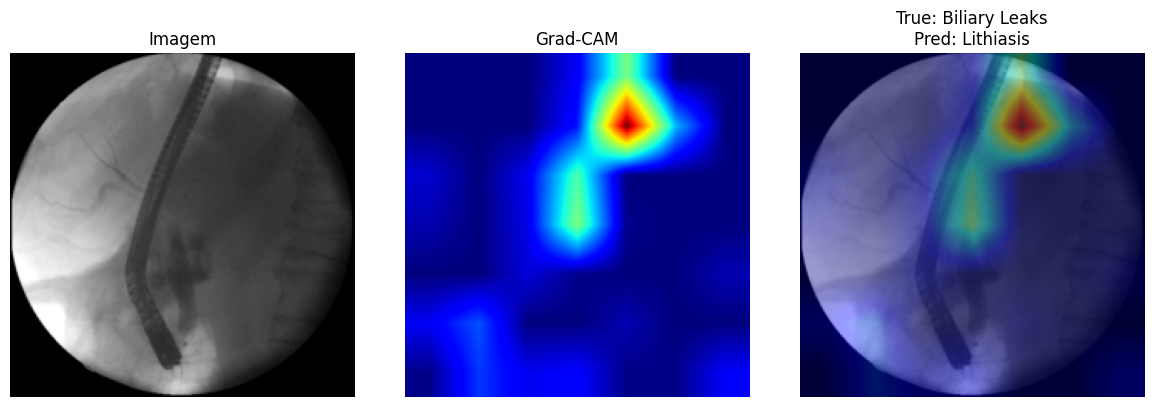

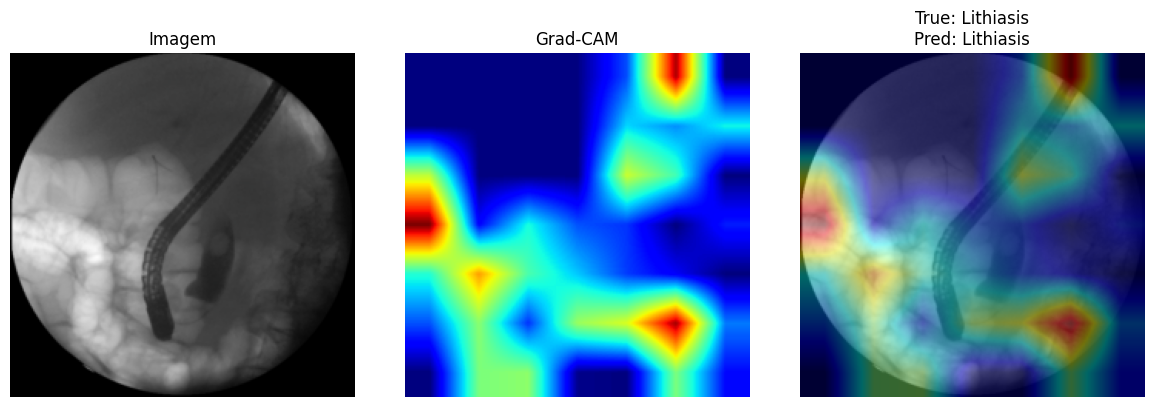

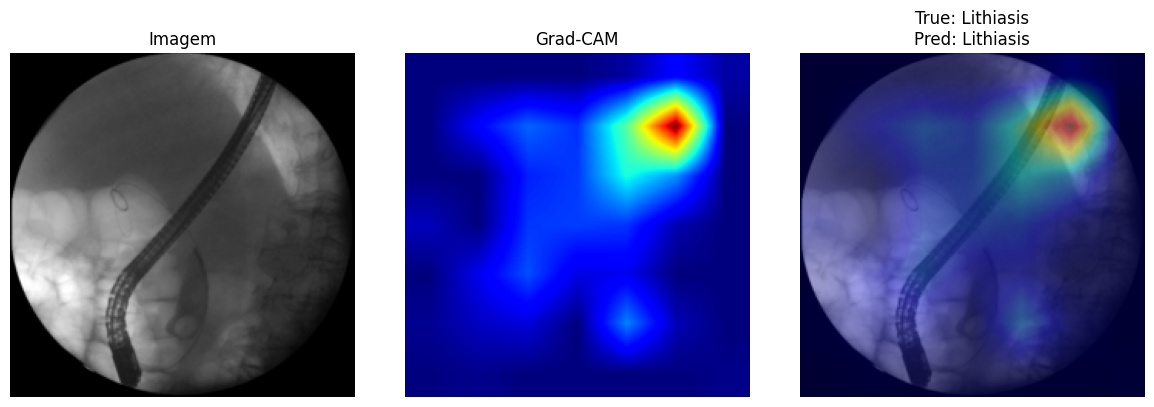

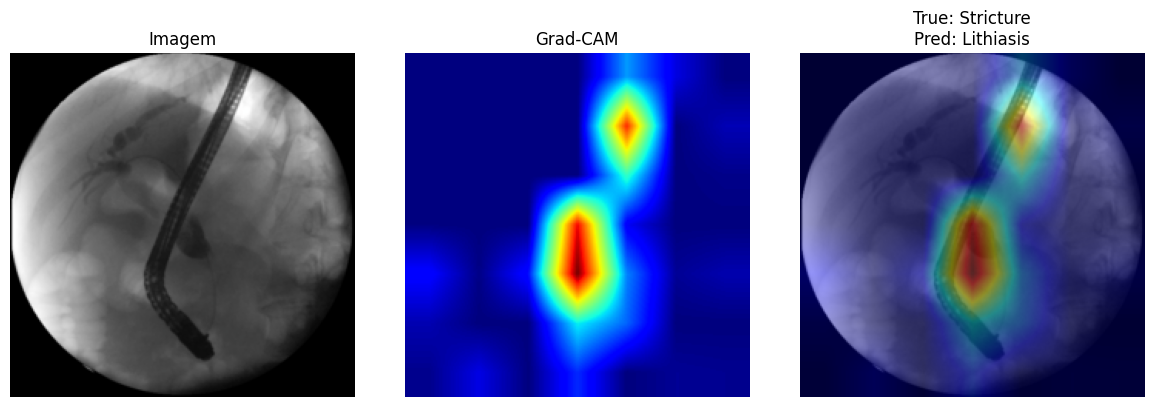

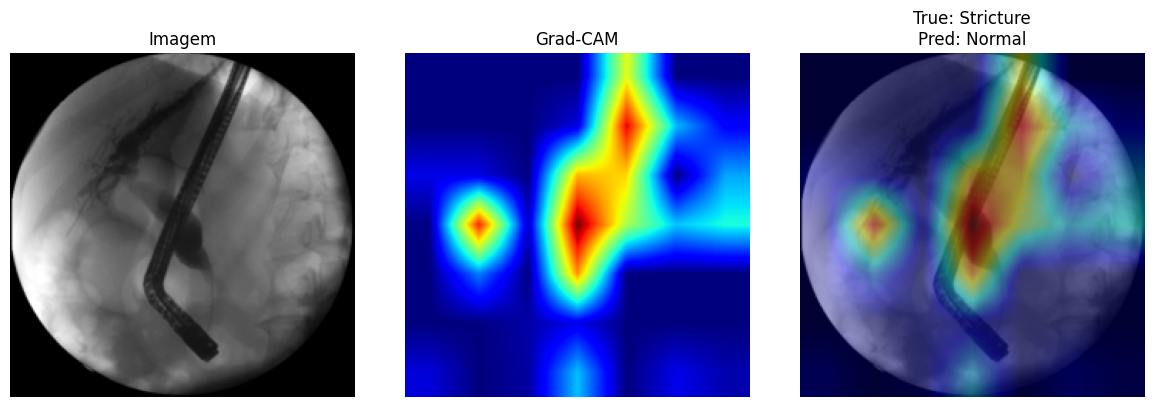

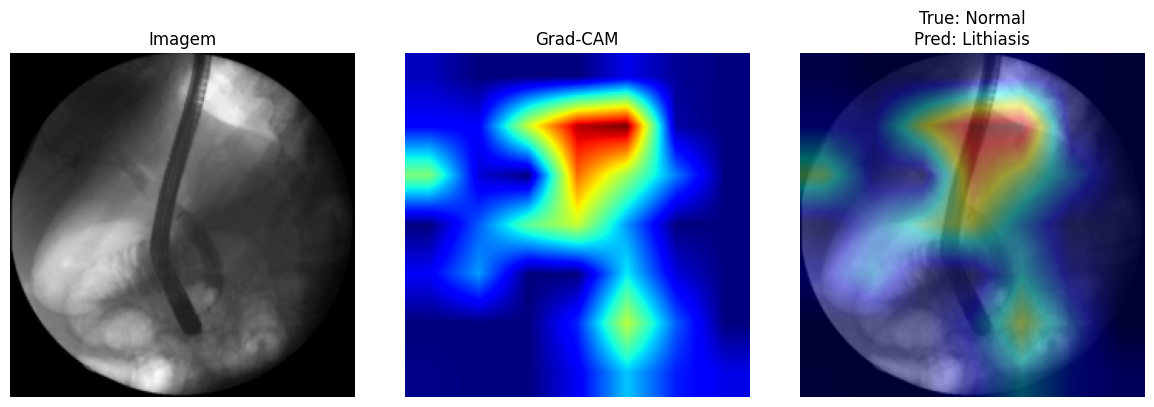

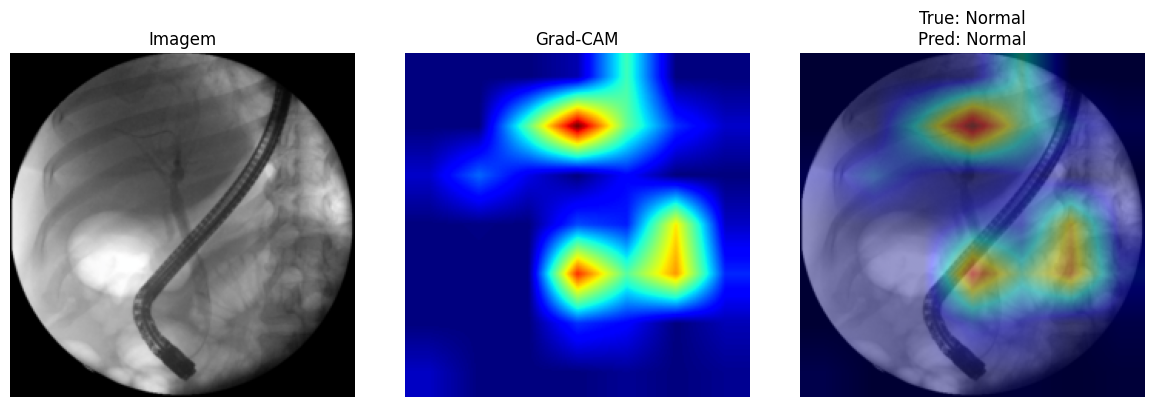

In [18]:
# =========================
# 16. Gerar Grad-CAM para exemplos do teste
# =========================

model.eval()
examples = []
for class_idx in range(len(class_names)):
    idxs = np.where(y_true == class_idx)[0][:2]
    examples.extend(list(idxs))

for n, idx in enumerate(examples):
    path = test_paths[idx]
    true_label = idx_to_class[int(y_true[idx])]
    pred_label = idx_to_class[int(y_pred[idx])]

    img = Image.open(path).convert("RGB")
    input_tensor = valid_tfms(img).unsqueeze(0).to(device)
    cam, logits = cam_generator.generate(input_tensor, class_idx=int(y_pred[idx]))
    img_denorm = denormalize(input_tensor.squeeze(0))
    overlay = overlay_cam(img_denorm, cam)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_denorm)
    axes[0].set_title("Imagem")
    axes[0].axis("off")
    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")
    axes[2].imshow(overlay)
    axes[2].set_title(f"True: {true_label}\nPred: {pred_label}")
    axes[2].axis("off")
    plt.tight_layout()
    out_path = RESULTS_DIR / f"gradcam_{n:02d}_{true_label}_pred_{pred_label}.png".replace(" ", "_")
    plt.savefig(out_path, dpi=200)
    plt.show()

cam_generator.close()


In [19]:
# =========================
# 17. Guardar resumo final
# =========================

summary = {
    "model": "RegNetY-400MF",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "macro_f1": float(macro_f1),
    "baseline_macro_f1": float(BASELINE_MACRO_F1),
    "difference_to_baseline": float(macro_f1 - BASELINE_MACRO_F1),
    "classes": class_names,
}

pd.DataFrame([summary]).to_csv(RESULTS_DIR / "summary.csv", index=False)
summary


{'model': 'RegNetY-400MF',
 'img_size': 224,
 'batch_size': 16,
 'accuracy': 0.41037735849056606,
 'balanced_accuracy': 0.33746936274509803,
 'macro_f1': 0.31784509023314994,
 'baseline_macro_f1': 0.738,
 'difference_to_baseline': -0.42015490976685005,
 'classes': ['Biliary Leaks', 'Lithiasis', 'Stricture', 'Normal']}